This code run under the Cebra conda environement on MacbookPro

In [39]:
import cebra
from cebra import CEBRA
import torch
if torch.cuda.is_available():
    print('using GPU')
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    print('using MPS')
    DEVICE = "mps"
else:
    print('using CPU')
    DEVICE = "cpu"

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pickle
import gc

using MPS


Load the data:
1. time varying spike count of 208 neurons for one sample time section of day one of PurWhi, file created by 1_Read_one_NWB_Site.ipynb
2. Behavioral annotation for periods of call-type playbacks, sensor activations and reward deliveries, file created by 1_Read_one_NWB_Site.ipynb

In [40]:
neuro_path = '/Users/elie/Library/CloudStorage/Box-Box/ManipBerkeleyZF/neuro_PurWhi_WF/'
filename = '%s/NeuralPop_activePeriod_countData_FS100.pkl' % (neuro_path)
neural_data = cebra.load_data(file=filename, key = 'neuralpop_data')
filename = '%s/Behavior_activePeriod_FS100.pkl' % (neuro_path)
with open(filename, 'rb') as file:
    data = pickle.load(file)
ct_dict = data['ct_dict']
del data
gc.collect()
time = cebra.load_data(file=filename, key = 'time')[0]
sensor_data = cebra.load_data(file=filename, key = 'sensor_data')[0]
reward_data = cebra.load_data(file=filename, key = 'reward_data')[0]
ct_data = cebra.load_data(file=filename, key = 'ct_data')[0]

FS=100

In [41]:
print('neural data length ' + str(neural_data.shape[1]))
print('time length ' + str(len(time)))
print('sensor_data length ' + str(len(sensor_data)))
print('reward_data length ' + str(len(reward_data)))
print('ct_data length ' + str(len(ct_data)))

neural data length 151500
time length 151500
sensor_data length 151500
reward_data length 151500
ct_data length 151500


In [42]:
# create the vector for hypercategories
print(ct_dict)
meaning_ct_dict = {'Alarm':('Th', 'Tu'), 'Agonistic':('Ag','Di'), 'Contact':('Te', 'DC','LT'), 'Pair-bond':('Wh','Ne'), 'Courtship':('So'), 'Food': ('Be')}
meaning_dict = {'Alarm':1, 'Agonistic':2, 'Contact':3, 'Pair-bond':4, 'Courtship':5, 'Food': 6}
print(meaning_ct_dict)
print(meaning_dict)
meaning_data = np.zeros(ct_data.shape)
for ct in ct_dict.keys():
    meaning = [k for k, v in meaning_ct_dict.items() if ct in v][0]
    meaning_data[ct_data == ct_dict[ct]] += meaning_dict[meaning]
print('meaning_data length ' + str(len(meaning_data)))

{'Th': 1, 'LT': 2, 'Di': 3, 'Wh': 4, 'Te': 5, 'Ne': 6, 'Be': 7, 'Tu': 8, 'So': 9, 'DC': 10, 'Ag': 11}
{'Alarm': ('Th', 'Tu'), 'Agonistic': ('Ag', 'Di'), 'Contact': ('Te', 'DC', 'LT'), 'Pair-bond': ('Wh', 'Ne'), 'Courtship': 'So', 'Food': 'Be'}
{'Alarm': 1, 'Agonistic': 2, 'Contact': 3, 'Pair-bond': 4, 'Courtship': 5, 'Food': 6}
meaning_data length 151500


In [43]:
print('recording duration:' + str(neural_data.shape[1]/100/60/60) + ' hrs or ' + str(neural_data.shape[1]/100/60) + ' min')
print('number of units: ' + str(neural_data.shape[0]))

recording duration:0.42083333333333334 hrs or 25.25 min
number of units: 208


Text(0.5, 1.0, 'Spike count data of 208 neurons first 30s')

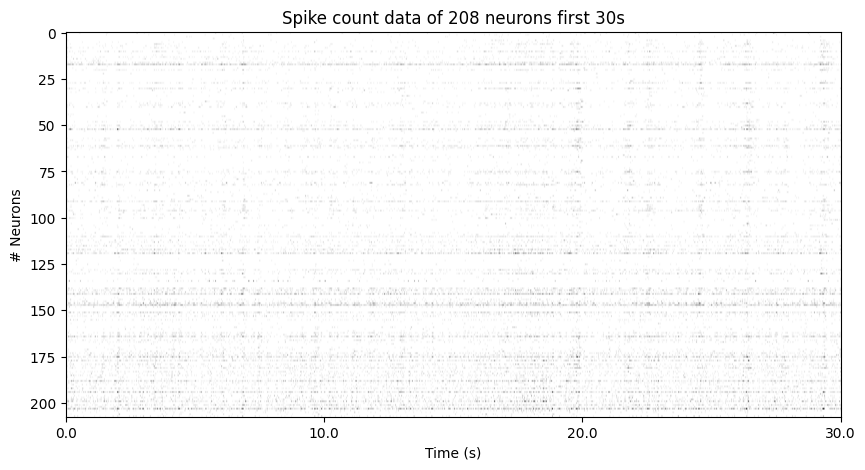

In [44]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,:30*FS], aspect = 'auto', vmax = np.round(100*neural_data[:,:30*FS].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 4))
ax1.set_xticklabels(np.linspace(0,30, 4))
ax1.set_title('Spike count data of 208 neurons first 30s')

In [45]:
# Split data and labels into train/validation

split_idx = int(0.8 * neural_data.shape[1])
# suggestion: 5%-20% depending on your dataset size; note that this splits the date
# into an early and late part, which might not be ideal for your data/experiment!
# As a more involved alternative, consider e.g. a nested time-series split.

train_data = neural_data.T[:split_idx]
valid_data = neural_data.T[split_idx:]
train_sensor = sensor_data[:split_idx]
valid_sensor = sensor_data[split_idx:]
train_reward = reward_data[:split_idx]
valid_reward = reward_data[split_idx:]
train_ct = ct_data[:split_idx]
valid_ct = ct_data[split_idx:]
train_meaning = meaning_data[:split_idx]
valid_meaning = meaning_data[split_idx:]
print(train_data.shape)
print(valid_data.shape)
print(train_sensor.shape)
print(valid_sensor.shape)
print(train_reward.shape)
print(valid_reward.shape)
print(train_ct.shape)
print(valid_ct.shape)
print(train_meaning.shape)
print(valid_meaning.shape)


(121200, 208)
(30300, 208)
(121200,)
(30300,)
(121200,)
(30300,)
(121200,)
(30300,)
(121200,)
(30300,)


In [64]:
# Matrix of discrete behavior labels
train_behavior = np.concatenate([train_sensor.reshape((train_sensor.size,1)), train_ct.reshape((train_ct.size,1)), train_meaning.reshape((train_meaning.size,1)), train_reward.reshape((train_reward.size,1))], axis=1)
valid_behavior = np.concatenate([valid_sensor.reshape((valid_sensor.size,1)), valid_ct.reshape((valid_ct.size,1)), valid_meaning.reshape((valid_meaning.size,1)), valid_reward.reshape((valid_reward.size,1))], axis=1)

In [47]:
# identify indices for the first two trials in the section (note that the first 3 sec of the first trial is truncated)
Time0 = 18765 # in s
TimeEnd = 20279.99 # in s
Trial1 = [18762.33, 18768.42] # in s
Trial2 = [18782.34, 18784.58] # in s
Trial3 = [18784.64, 18787.27] # in s
Trial4 = [18787.32, 18791.06] # in s

Ind_first4trials = [0, int((Trial4[1]-Time0)*FS)] # in train_data.shape

Trial5end = [20259.66, 20261.5]
Trial4end = [20261.57, 20267.74]
Trial3end = [20274.07, 20275.78]
Trial2end = [20275.85, 20277.71]
Trial1end = [20277.81, 20283.19]
Ind_last5trials = [int((Trial5end[0]-TimeEnd)*FS-1) ,-1] # in valid_data.shape and in neural_data

Text(0.5, 1.0, 'All Trials during requested section')

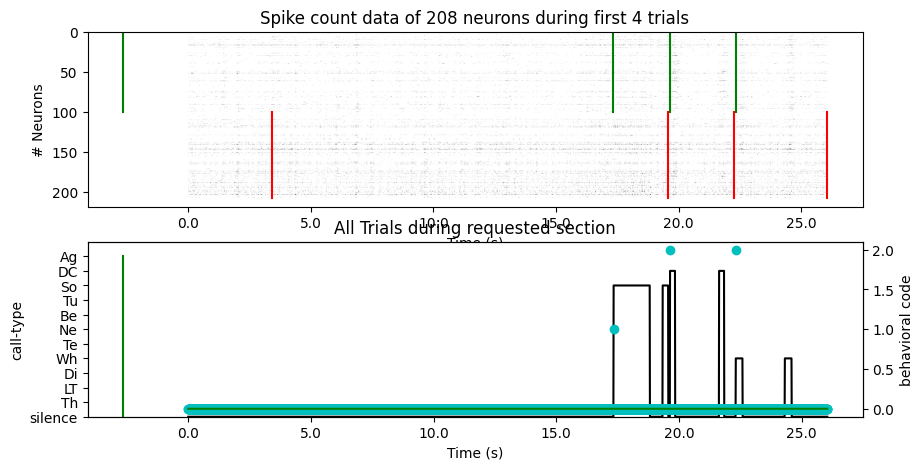

In [48]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(2,1,1)
ax1.imshow(neural_data[:,Ind_first4trials[0]:Ind_first4trials[1]], aspect = 'auto', vmax = np.round(100*neural_data[:,Ind_first4trials[0]:Ind_first4trials[1]].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 7))
ax1.set_xticklabels(np.linspace(0,30, 7))
ax1.set_title('Spike count data of 208 neurons during first 4 trials')
ax1.plot([(Trial2[0] - Time0)*FS, (Trial2[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial1[0] - Time0)*FS, (Trial1[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial3[0] - Time0)*FS, (Trial3[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial4[0] - Time0)*FS, (Trial4[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial2[1] - Time0)*FS, (Trial2[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial1[1] - Time0)*FS, (Trial1[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial3[1] - Time0)*FS, (Trial3[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial4[1] - Time0)*FS, (Trial4[1] - Time0)*FS], [100, 208], color='red')

# of the behavioral data output
section_plot = [Ind_first4trials[0], Ind_first4trials[1]] # in s
ax2 = plt.subplot(2, 1,2)#, sharex=ax1)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('call-type')
ax2.set_yticks(np.array(range(0,len(ct_dict.keys())+1)))
ax2.set_yticklabels(['silence'] + list( ct_dict.keys()))
ax2.set_ylim([0,12])
ax2.plot(ct_data[section_plot[0]:section_plot[1]], 'k-') # code for call-type
ax2.set_xticks(np.linspace(0,30*FS, 7))
ax2.set_xticklabels(np.linspace(0,30, 7))
ax2.plot([(Trial1[0] - Time0)*FS, (Trial1[0] - Time0)*FS], [0, 11], color='green')
ax3 = ax2.twinx()
ax3.plot(sensor_data[section_plot[0]:section_plot[1]], 'c', marker='o', markersize=6, linestyle='None') # pecking event
ax3.plot(reward_data[section_plot[0]:section_plot[1]], 'g-') # reward vector

ax3.set_ylabel('behavioral code')
ax2.set_title('All Trials during requested section')

Text(0.5, 1.0, 'All Trials during requested section')

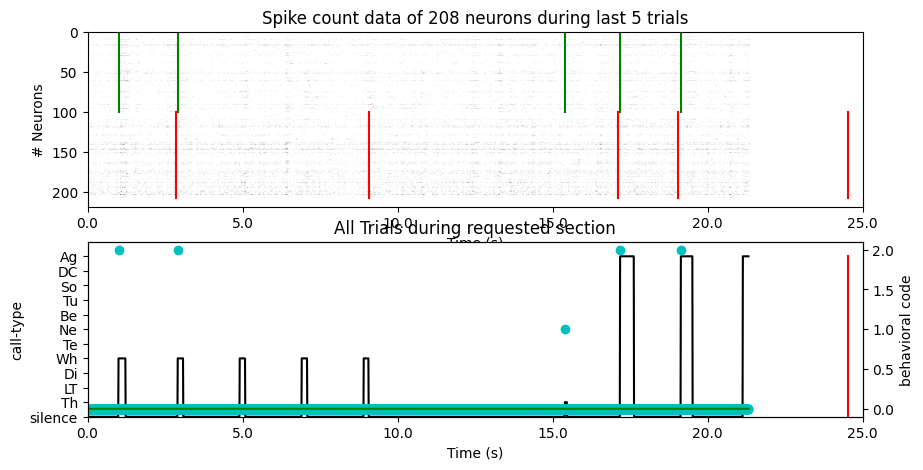

In [49]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(2,1,1)
ax1.imshow(neural_data[:,Ind_last5trials[0]-FS:Ind_last5trials[1]], aspect = 'auto', vmax = np.round(100*neural_data[:,Ind_last5trials[0]-FS:Ind_last5trials[1]].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xlim([0,25*FS])
ax1.set_xticks(np.linspace(0,25*FS, 6))
ax1.set_xticklabels(np.linspace(0,25, 6))
ax1.set_title('Spike count data of 208 neurons during last 5 trials')
ax1.plot([FS, FS], [0, 100], color='green')
ax1.plot([(Trial4end[0]*FS - (Trial5end[0]*FS -FS)), (Trial4end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial3end[0]*FS - (Trial5end[0]*FS -FS)), (Trial3end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial2end[0]*FS - (Trial5end[0]*FS -FS)), (Trial2end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial1end[0]*FS - (Trial5end[0]*FS -FS)), (Trial1end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial5end[1]*FS - (Trial5end[0]*FS -FS)), (Trial5end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial4end[1]*FS - (Trial5end[0]*FS -FS)), (Trial4end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial3end[1]*FS - (Trial5end[0]*FS -FS)), (Trial3end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial2end[1]*FS - (Trial5end[0]*FS -FS)), (Trial2end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial1end[1]*FS - (Trial5end[0]*FS -FS)), (Trial1end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')

# of the behavioral data output
section_plot = [Ind_last5trials[0]-FS, Ind_last5trials[1]] # in s
ax2 = plt.subplot(2, 1,2)#, sharex=ax1)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('call-type')
ax2.plot(ct_data[section_plot[0]:section_plot[1]], 'k-') # code for call-type
ax2.set_yticks(np.array(range(0,len(ct_dict.keys())+1)))
ax2.set_yticklabels(['silence'] + list( ct_dict.keys()))
ax2.set_ylim([0,12])
ax2.set_xticks(np.linspace(0,25*FS, 6))
ax2.set_xticklabels(np.linspace(0,25, 6))
ax2.set_xlim([0, 25*FS])
ax2.plot([(Trial1end[1]*FS - (Trial5end[0]*FS -FS)), (Trial1end[1]*FS - (Trial5end[0]*FS -FS))], [0, 11], color='red')

ax3 = ax2.twinx()
ax3.plot(sensor_data[section_plot[0]:section_plot[1]], 'c', marker='o', markersize=6, linestyle='None') # pecking event
ax3.plot(reward_data[section_plot[0]:section_plot[1]], 'g-') # reward vector
ax3.set_ylabel('behavioral code')
ax2.set_title('All Trials during requested section')


In [50]:
def plot_cebra(embtrain, embval, cebra_model, label, sensortrain = np.array([]), rewardtrain =np.array([]), vocstrain=np.array([]),sensorval=np.array([]), rewardval=np.array([]), vocsval=np.array([]), dict_ct=[], PlotLossFlag=True, Dim = [0,1,2]):
    # The standard color table of Etho Call-types except for song which is coded in grey here and adding silence in black
    callColor = {
        'Be':(0/255.0, 230/255.0, 255/255.0),
        'Tu':(255/255.0, 200/255.0, 65/255.0),
        'Th':(255/255.0, 150/255.0, 40/255.0),
        'Di':(255/255.0, 105/255.0, 15/255.0),
        'Ag':(255/255.0, 0/255.0, 0/255.0),
        'Wh':(255/255.0, 180/255.0, 255/255.0),
        'Ne':(255/255.0, 100/255.0, 255/255.0),
        'Te':(140/255.0, 100/255.0, 185/255.0),
        'DC':(100/255.0, 50/255.0, 200/255.0),
        'LT':(0/255.0, 95/255.0, 255/255.0),
        'So':(100/255,100/255,100/255), 
        'Silence':(0,0,0)}
    
    # prepare the color vector for training set
    if not (sensortrain.size==0 & rewardtrain.size==0 & vocstrain.size==0):
        colors = np.zeros((len(embtrain[:,0]),3)) # initialize the vector with all black shapes
        for ct in dict_ct.keys():
            colors[vocstrain == dict_ct[ct],:] += callColor[ct] # add the color of each call-type when it is being played
        colors[rewardtrain == 1,:] += (255/255.0, 255/255.0, 0) # yellow color
    else:
        colors = np.tile(np.arange(100),int(embtrain.shape[0]/100)+1)
        colors = colors[:len(embtrain[:,0])]

    # plot the embedding for training set
    print('plotting the embedding for training data')
    fig1 = plt.figure(figsize=(15,5))
    ax1 = fig1.add_subplot(1,2,1, projection='3d') # Initialize 3D axes
    if sensortrain.size==0 & rewardtrain.size==0 & vocstrain.size==0:
        ax1.scatter(embtrain[:,Dim[0]], embtrain[:,Dim[1]], embtrain[:,Dim[2]], cmap = 'magma', c = colors, s=1)
    else:
        NoReNosensor = (rewardtrain==0) & (sensortrain==0)
        ax1.scatter(embtrain[NoReNosensor,Dim[0]], embtrain[NoReNosensor,Dim[1]], embtrain[NoReNosensor,Dim[2]], c = colors[NoReNosensor,:], s=1)
        ax1.scatter(embtrain[rewardtrain==1,Dim[0]], embtrain[rewardtrain==1,Dim[1]], embtrain[rewardtrain==1,Dim[2]], c = colors[rewardtrain==1,:], s=10, marker = 's')
        ax1.scatter(embtrain[sensortrain==1,Dim[0]], embtrain[sensortrain==1,Dim[1]], embtrain[sensortrain==1,Dim[2]], c = colors[sensortrain==1,:], s=20, marker = '*')
    ax1.set_title("Embedding train set " + label)
    ax1.set_xlabel('Dim ' + str(Dim[0]))
    ax1.set_ylabel('Dim ' + str(Dim[1]))
    ax1.set_zlabel('Dim ' + str(Dim[2]))

    # prepare the color vector for validating set
    if not (sensorval.size==0 & rewardval.size==0 & vocsval.size==0):
        colors = np.zeros((len(embval[:,0]),3)) # initialize the vector with all black shapes
        for ct in dict_ct.keys():
            colors[vocsval == dict_ct[ct],:] += callColor[ct] # add the color of each call-type when it is being played
        colors[rewardval == 1,:] += (255/255.0, 255/255.0, 0) # yellow color
    else:
        colors = np.tile(np.arange(100),int(embval.shape[0]/100)+1)
        colors = colors[:len(embval[:,0])]

    # plot the embedding for validating set
    print('plotting the embedding for validating data')
    ax2 = fig1.add_subplot(1,2,2, projection='3d') # Initialize 3D axes
    if (sensorval.size==0 & rewardval.size==0 & vocsval.size==0):
        ax2.scatter(embval[:,Dim[0]], embval[:,Dim[1]], embval[:,Dim[2]], cmap = 'magma', c = colors, s=1)
    else:
        NoReNosensor = (rewardval==0) & (sensorval==0)
        ax2.scatter(embval[NoReNosensor,Dim[0]], embval[NoReNosensor,Dim[1]], embval[NoReNosensor,Dim[2]], c = colors[NoReNosensor,:], s=1)
        ax2.scatter(embval[rewardval==1,Dim[0]], embval[rewardval==1,Dim[1]], embval[rewardval==1,Dim[2]], c = colors[rewardval==1,:], s=10, marker = 's')
        ax2.scatter(embval[sensorval==1,Dim[0]], embval[sensorval==1,Dim[1]], embval[sensorval==1,Dim[2]], c = colors[sensorval==1,:], s=20, marker = '*')
    ax2.set_title("Embedding Valid set " + label)
    ax2.set_xlabel('Dim ' + str(Dim[0]))
    ax2.set_ylabel('Dim ' + str(Dim[1]))
    ax2.set_zlabel('Dim ' + str(Dim[2]))

    if PlotLossFlag:
        fig2 = plt.figure(figsize=(15,5))
        # plot the loss
        print('plotting the Loss')
        ax3 = fig2.add_subplot(1,2,1)
        cebra.plot_loss(cebra_model, ax=ax3)
        ax3.set_title("Loss " + label)

        # plot the goodness of fit history
        print('plotting the goodness of fit')
        ax4 = fig2.add_subplot(1,2,2)
        gof_valid_history = cebra.sklearn.metrics.goodness_of_fit_history(cebra_model)
        ax4.plot(gof_valid_history)
        ax4.set_title("GoF " + label)

In [51]:
def gettrialmask(sensor, reward, ct, ntrial=5):
    # get the indices of all points that correspond to the x first trials
    # initialize boolean vector of the size of the input
    mask = np.full(sensor.shape[0], True)
    # vector of all the time points'indices when there is either a vocalization being played or a reward being delivered
    activity = np.nonzero(sensor + reward + ct)[0]
    # identify all ntrial onsets
    trial_init_all = np.nonzero(sensor)[0][0:(ntrial+1)]
    # identify the time points when sensor is == 1 (initialization of a trial without interruption) among these first trials
    trial_init = np.where(sensor==1)[0]
    trial_init = trial_init[trial_init<=trial_init_all.max()]
    # loop through trials initiations that were not interruption and set to False all the time points that preceed it up to the last activity (being reward or sound being played)
    for it in trial_init:
        if it == trial_init[0]: # this is the first trial set everything before to zero
            mask[0:it] = False
        else:
            diff_indices = it - activity
            diff_indices = diff_indices[diff_indices>0] # only keep the events that happened before it
            if diff_indices.size>0:
                last_activity = it-diff_indices.min()
                mask[(last_activity + 1):it] = False
            else:
                raise ValueError("there is no activity before this trial onset although it's neither the first trial, nor an interruption event")
    # mask everything that is after the last requested trial
    mask[trial_init_all[-1]:] = False
    return mask

In [52]:
import cebra.models
print(str(len(cebra.models.get_options())) + ' different models')
print(cebra.models.get_options())
print(str(len(cebra.models.get_options('resample*'))) + ' resample models')
print(cebra.models.get_options('resample*'))
print(str(len(cebra.models.get_options('offset*'))) + ' offset models')
print(cebra.models.get_options('offset*'))
print(str(len(cebra.models.get_options('supervised*'))) + ' supervised models')
print(cebra.models.get_options('supervised*'))


147 different models
['offset10-model', 'offset10-model-mse', 'offset5-model', 'offset1-model-mse', 'offset1-model', 'offset1-model-v2', 'offset1-model-v3', 'offset1-model-v4', 'offset1-model-v5', 'offset40-model-4x-subsample', 'resample-model', 'offset20-model-4x-subsample', 'resample5-model', 'offset4-model-2x-subsample', 'resample1-model', 'supervised10-model', 'supervised1-model', 'offset36-model', 'offset36-model-dropout', 'offset36-model-more-dropout', 'offset40-model', 'offset50-model', 'offset15-model', 'offset20-model', 'offset10-model-mse-tanh', 'offset1-model-mse-tanh', 'offset1-model-mse-clip-1000-1000', 'offset1-model-mse-clip-1000-100', 'offset1-model-mse-clip-1000-50', 'offset1-model-mse-clip-1000-25', 'offset1-model-mse-clip-1000-20', 'offset1-model-mse-clip-1000-15', 'offset1-model-mse-clip-1000-10', 'offset1-model-mse-clip-1000-5', 'offset1-model-mse-clip-1000-1', 'offset1-model-mse-clip-100-1000', 'offset1-model-mse-clip-100-100', 'offset1-model-mse-clip-100-50', 'of

When defining a model, the parameter time_offsets define the distance in time steps between each reference index and its positive sample for the time contrastive learning.
The Offset parameter defined by the model architecture (ex: offset10-model vs offset5-model) corresponds to the width of the data matrix that is extrated from the data for each sample (ref, pos or neg) and centered around the time of the sample. This matrix is then fed to the convolutional neural network to calculate and optimize sample distances (it is sort of the size of the receptive field).

In our usage case, with a data sample frequency of 100Hz, and sound events that can be as short as 70ms, we want to fix the offset of the model architecture to ~ 5 time steps = 50ms (20ms before 30ms after) and so for time contrastive learning, where the positive sample of a given ref sample is just time-offset further (after) than the ref sample, we want to fix time_offset to a larger value. Let's explore a bit the performances of the behav model with various combinations of offset and size of receptive field..

Exploring the effect of changing the model architecture with fix dimension of 5

In [53]:
# Define fix parameters
Output_dim = 5
Time_offset = 1

CEBRA(batch_size=2048, conditional='time_delta', device='mps',
      learning_rate=0.001, max_iterations=5000,
      model_architecture='offset5-model', output_dimension=5, verbose=True)
Fitting the model


pos: -0.6548 neg:  7.9520 total:  7.2972 temperature:  1.0000: 100%|██████████| 5000/5000 [08:53<00:00,  9.38it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit
plotting the embedding for training data
plotting the embedding for validating data


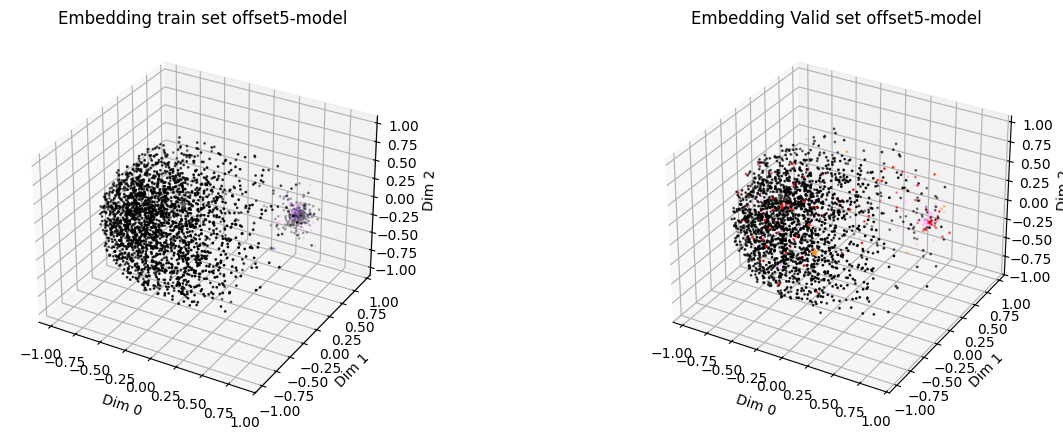

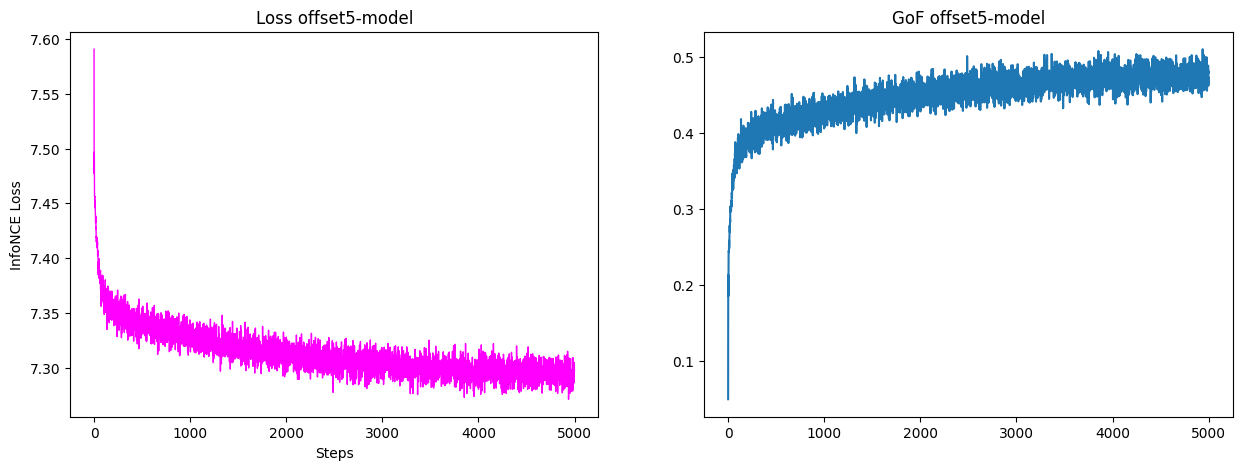

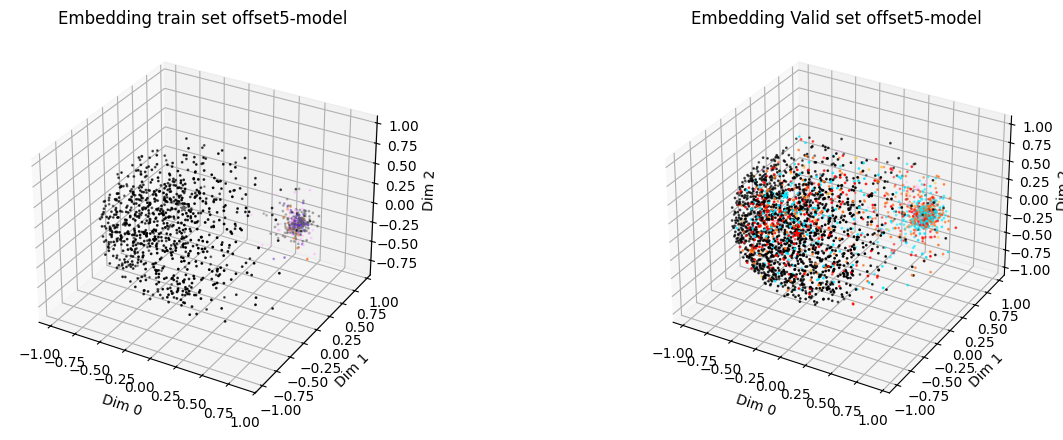

In [54]:
Model_arch = "offset5-model"
cebra_Offset5 = CEBRA(
    model_architecture = Model_arch,
    conditional = 'time_delta',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True,
    hybrid = False
)

print(cebra_Offset5)

# fit the model
print('Fitting the model')
cebra_Offset5.fit(train_data, train_behavior)

# obtain the embedding on training set
print('calculating the training embedding')
embtrain = cebra_Offset5.transform(train_data)
assert(embtrain.shape == (train_data.shape[0],Output_dim))


# obtain the embedding on validating set
print('calculating the validating embedding')
embval = cebra_Offset5.transform(valid_data)
assert(embval.shape == (valid_data.shape[0],Output_dim))


plot_cebra(embtrain[Ind_first4trials[0]:Ind_first4trials[1],:], embval[Ind_last5trials[0]-FS:Ind_last5trials[1],:], cebra_Offset5, Model_arch, train_sensor[Ind_first4trials[0]:Ind_first4trials[1]], train_reward[Ind_first4trials[0]:Ind_first4trials[1]], train_ct[Ind_first4trials[0]:Ind_first4trials[1]], valid_sensor[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_reward[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_ct[Ind_last5trials[0]-FS:Ind_last5trials[1]], ct_dict)
mask_train = gettrialmask(train_sensor, train_reward, train_ct)
mask_val = gettrialmask(valid_sensor, valid_reward, valid_ct)
plot_cebra(embtrain[mask_train,:], embval[mask_val,:], cebra_Offset5, Model_arch, train_sensor[mask_train], train_reward[mask_train], train_ct[mask_train], valid_sensor[mask_val], valid_reward[mask_val], valid_ct[mask_val], ct_dict, PlotLossFlag=False)

CEBRA(batch_size=2048, conditional='time_delta', device='mps',
      learning_rate=0.001, max_iterations=5000,
      model_architecture='offset10-model', output_dimension=5)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit
plotting the embedding for training data
plotting the embedding for validating data


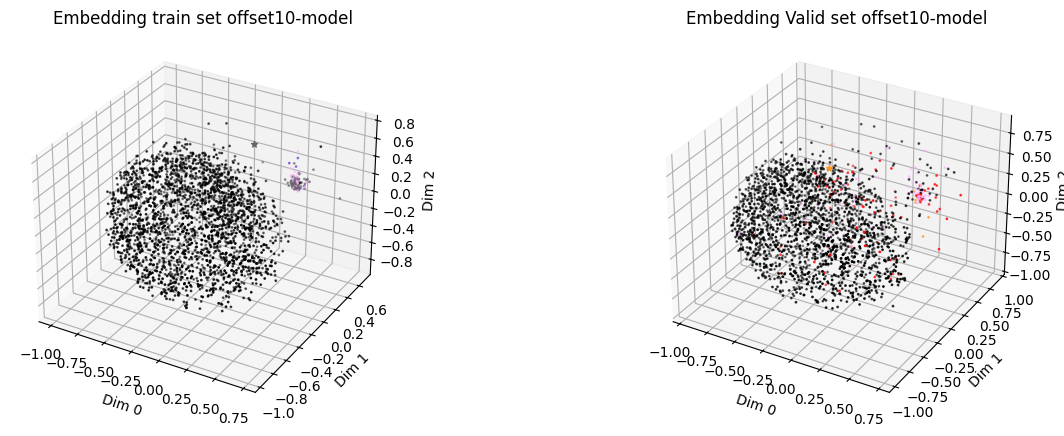

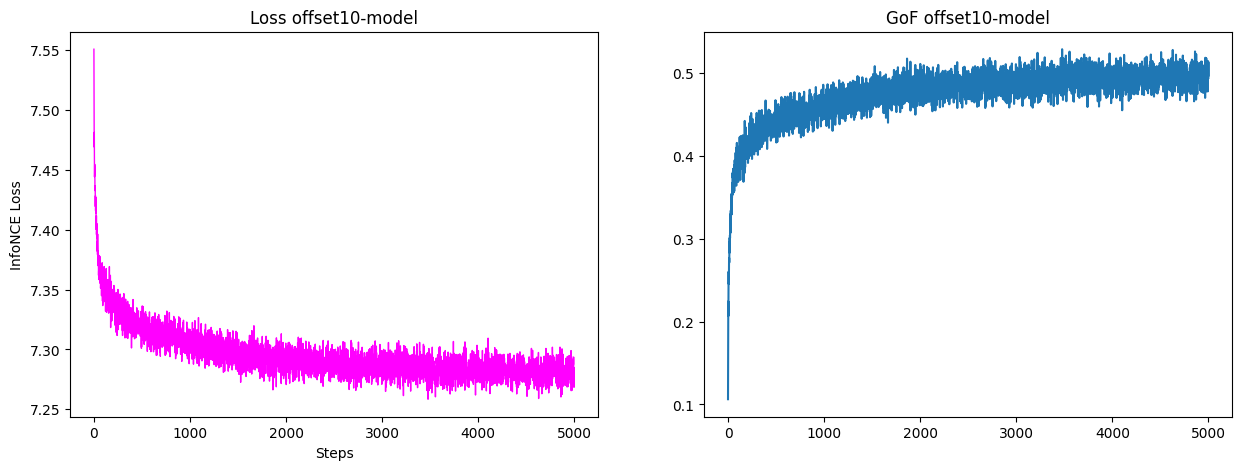

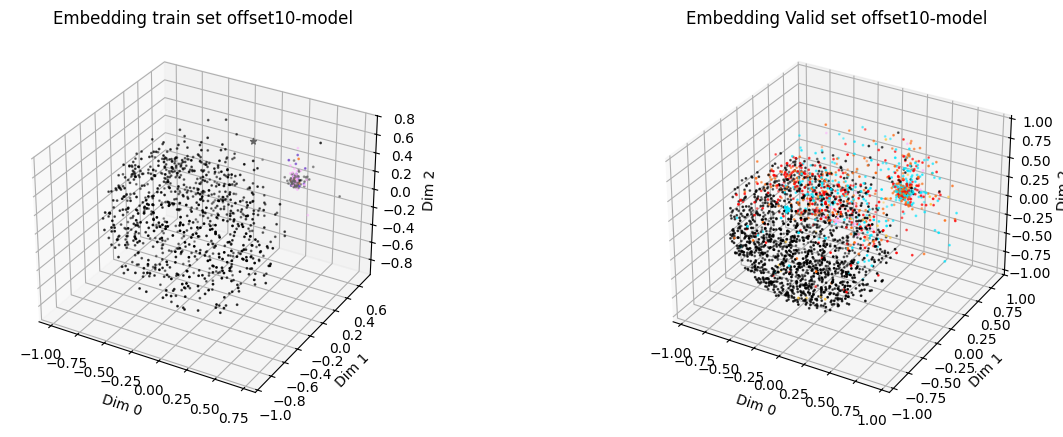

In [55]:
Model_arch = "offset10-model"
cebra_Offset10 = CEBRA(
    model_architecture = Model_arch,
    conditional = 'time_delta',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False,
    hybrid = False
)

print(cebra_Offset10)

# fit the model
print('Fitting the model')
cebra_Offset10.fit(train_data, train_behavior)

# obtain the embedding on training set
print('calculating the training embedding')
embtrain = cebra_Offset10.transform(train_data)
assert(embtrain.shape == (train_data.shape[0],Output_dim))

# obtain the embedding on validating set
print('calculating the validating embedding')
embval = cebra_Offset10.transform(valid_data)
assert(embval.shape == (valid_data.shape[0],Output_dim))


plot_cebra(embtrain[Ind_first4trials[0]:Ind_first4trials[1],:], embval[Ind_last5trials[0]-FS:Ind_last5trials[1],:], cebra_Offset10, Model_arch, train_sensor[Ind_first4trials[0]:Ind_first4trials[1]], train_reward[Ind_first4trials[0]:Ind_first4trials[1]], train_ct[Ind_first4trials[0]:Ind_first4trials[1]], valid_sensor[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_reward[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_ct[Ind_last5trials[0]-FS:Ind_last5trials[1]], ct_dict)
mask_train = gettrialmask(train_sensor, train_reward, train_ct)
mask_val = gettrialmask(valid_sensor, valid_reward, valid_ct)
plot_cebra(embtrain[mask_train,:], embval[mask_val,:], cebra_Offset10, Model_arch, train_sensor[mask_train], train_reward[mask_train], train_ct[mask_train], valid_sensor[mask_val], valid_reward[mask_val], valid_ct[mask_val], ct_dict, PlotLossFlag=False)


CEBRA(batch_size=2048, conditional='time_delta', device='mps',
      learning_rate=0.001, max_iterations=5000, output_dimension=5)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit
plotting the embedding for training data
plotting the embedding for validating data


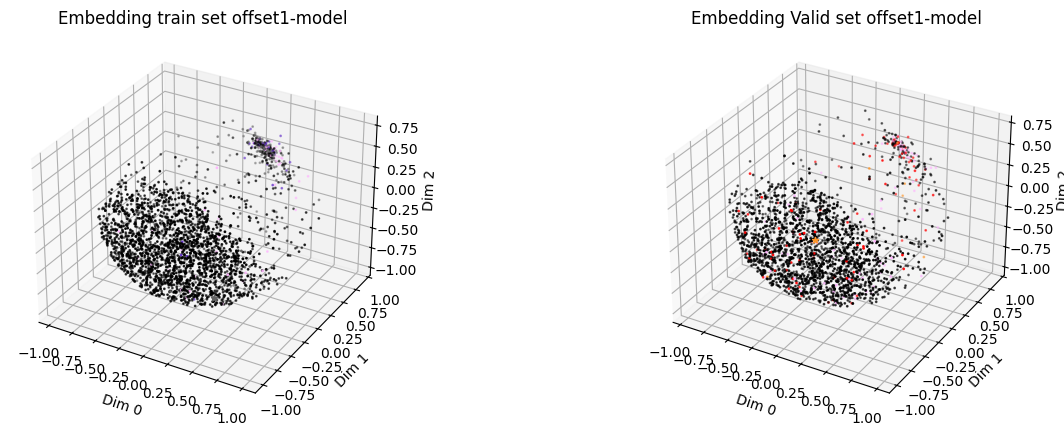

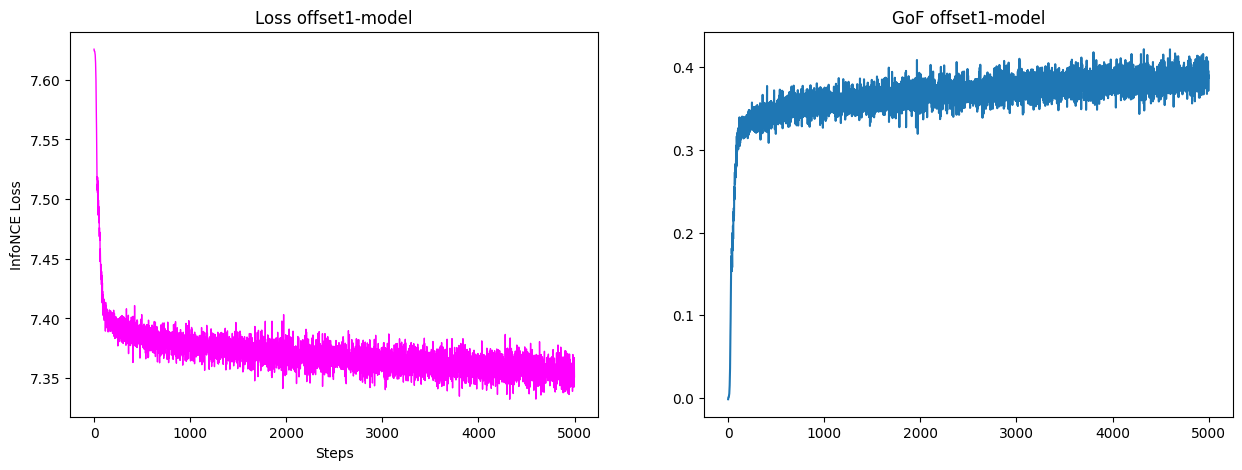

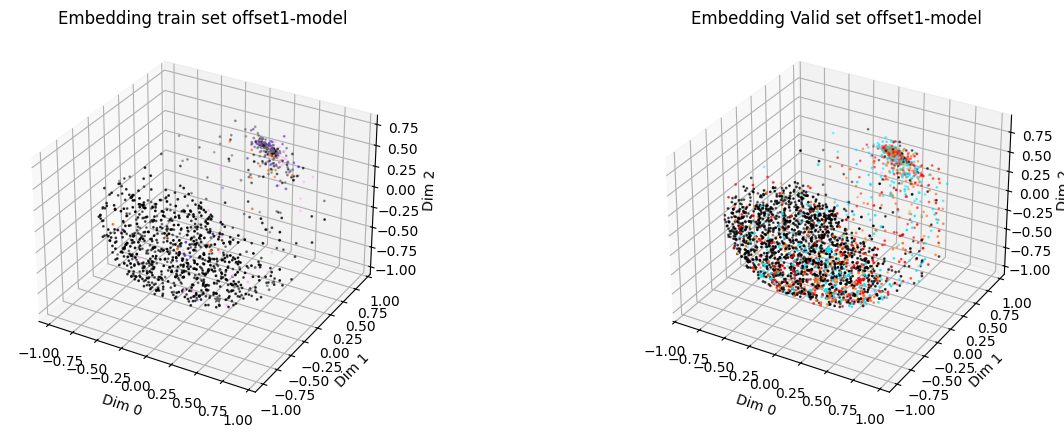

In [56]:
Model_arch = "offset1-model"
cebra_Offset1 = CEBRA(
    model_architecture = Model_arch,
    conditional = 'time_delta',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False,
    hybrid = False
)

print(cebra_Offset1)

# fit the model
print('Fitting the model')
cebra_Offset1.fit(train_data, train_behavior)

# obtain the embedding on training set
print('calculating the training embedding')
embtrain = cebra_Offset1.transform(train_data)
assert(embtrain.shape == (train_data.shape[0],Output_dim))

# obtain the embedding on validating set
print('calculating the validating embedding')
embval = cebra_Offset1.transform(valid_data)
assert(embval.shape == (valid_data.shape[0],Output_dim))

plot_cebra(embtrain[Ind_first4trials[0]:Ind_first4trials[1],:], embval[Ind_last5trials[0]-FS:Ind_last5trials[1],:], cebra_Offset1, Model_arch, train_sensor[Ind_first4trials[0]:Ind_first4trials[1]], train_reward[Ind_first4trials[0]:Ind_first4trials[1]], train_ct[Ind_first4trials[0]:Ind_first4trials[1]], valid_sensor[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_reward[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_ct[Ind_last5trials[0]-FS:Ind_last5trials[1]], ct_dict)
mask_train = gettrialmask(train_sensor, train_reward, train_ct)
mask_val = gettrialmask(valid_sensor, valid_reward, valid_ct)
plot_cebra(embtrain[mask_train,:], embval[mask_val,:], cebra_Offset1, Model_arch, train_sensor[mask_train], train_reward[mask_train], train_ct[mask_train], valid_sensor[mask_val], valid_reward[mask_val], valid_ct[mask_val], ct_dict, PlotLossFlag=False)


CEBRA(batch_size=2048, conditional='time_delta', device='mps',
      learning_rate=0.001, max_iterations=5000,
      model_architecture='offset36-model', output_dimension=5, verbose=True)
Fitting the model


pos: -0.6838 neg:  7.9638 total:  7.2800 temperature:  1.0000: 100%|██████████| 5000/5000 [28:35<00:00,  2.91it/s]     


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit
plotting the embedding for training data
plotting the embedding for validating data


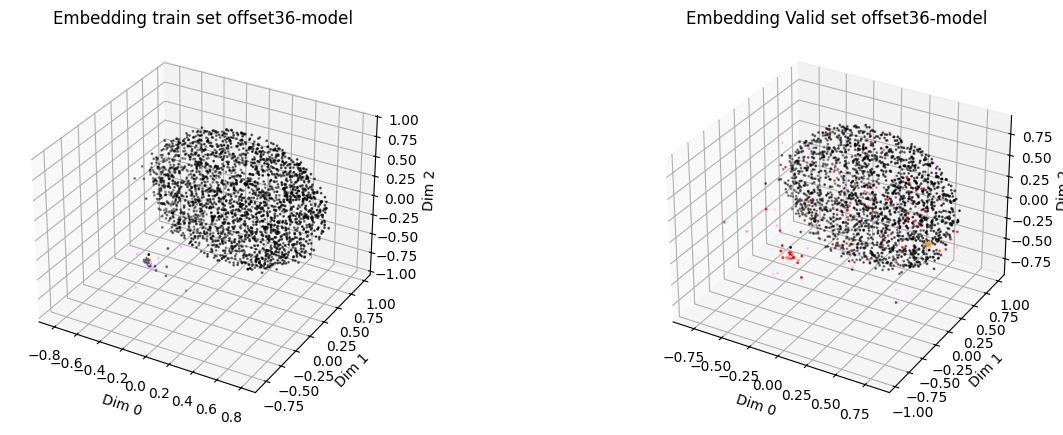

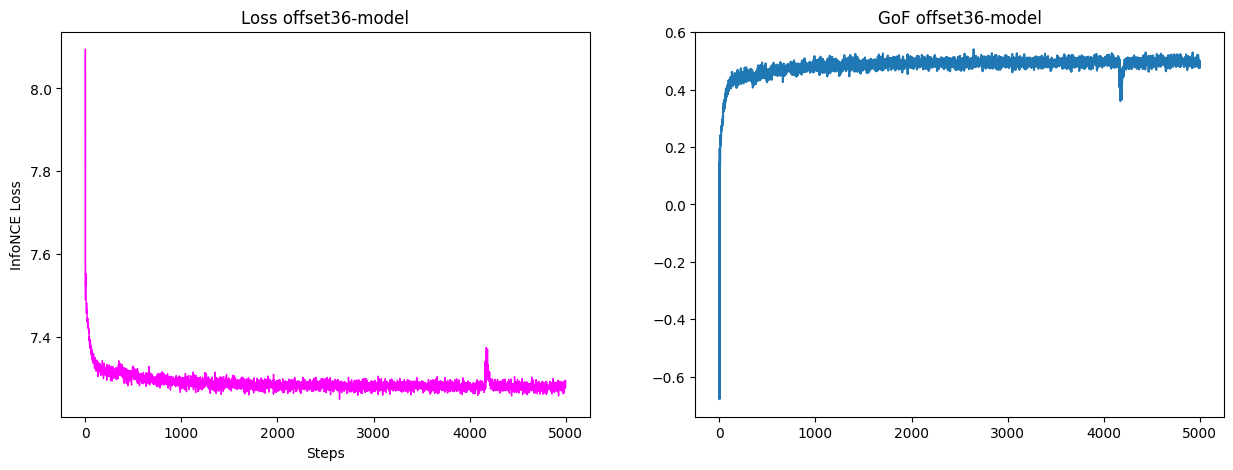

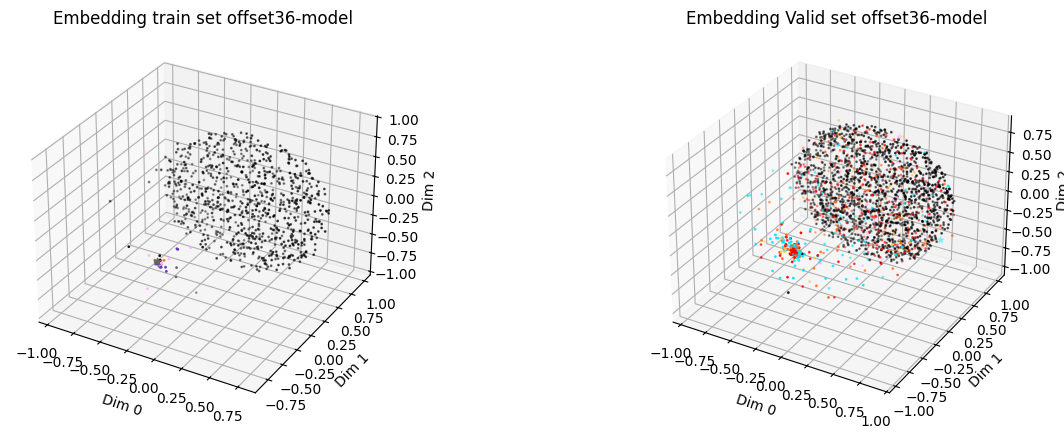

In [57]:
Model_arch = "offset36-model" 
cebra_Offset36= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time_delta',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True,
    hybrid = False
)

print(cebra_Offset36)

# fit the model
print('Fitting the model')
cebra_Offset36.fit(train_data, train_behavior)

# obtain the embedding on training set
print('calculating the training embedding')
embtrain = cebra_Offset36.transform(train_data)
assert(embtrain.shape == (train_data.shape[0],Output_dim))


# obtain the embedding on validating set
print('calculating the validating embedding')
embval = cebra_Offset36.transform(valid_data)
assert(embval.shape == (valid_data.shape[0],Output_dim))

plot_cebra(embtrain[Ind_first4trials[0]:Ind_first4trials[1],:], embval[Ind_last5trials[0]-FS:Ind_last5trials[1],:], cebra_Offset36, Model_arch, train_sensor[Ind_first4trials[0]:Ind_first4trials[1]], train_reward[Ind_first4trials[0]:Ind_first4trials[1]], train_ct[Ind_first4trials[0]:Ind_first4trials[1]], valid_sensor[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_reward[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_ct[Ind_last5trials[0]-FS:Ind_last5trials[1]], ct_dict)
mask_train = gettrialmask(train_sensor, train_reward, train_ct)
mask_val = gettrialmask(valid_sensor, valid_reward, valid_ct)
plot_cebra(embtrain[mask_train,:], embval[mask_val,:], cebra_Offset36, Model_arch, train_sensor[mask_train], train_reward[mask_train], train_ct[mask_train], valid_sensor[mask_val], valid_reward[mask_val], valid_ct[mask_val], ct_dict, PlotLossFlag=False)


CEBRA(batch_size=2048, conditional='time_delta', device='mps',
      learning_rate=0.001, max_iterations=5000,
      model_architecture='offset40-model', output_dimension=5, verbose=True)
Fitting the model


pos: -0.6872 neg:  7.9645 total:  7.2772 temperature:  1.0000: 100%|██████████| 5000/5000 [13:49<00:00,  6.03it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit
plotting the embedding for training data
plotting the embedding for validating data


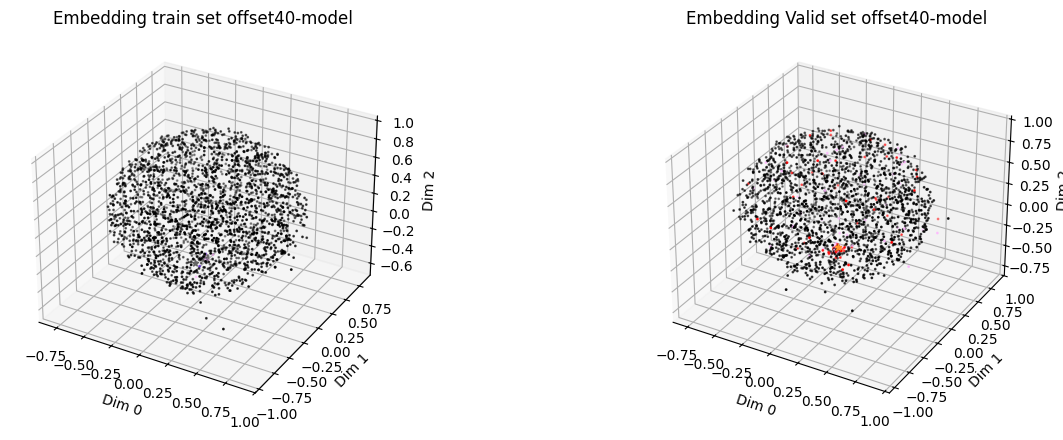

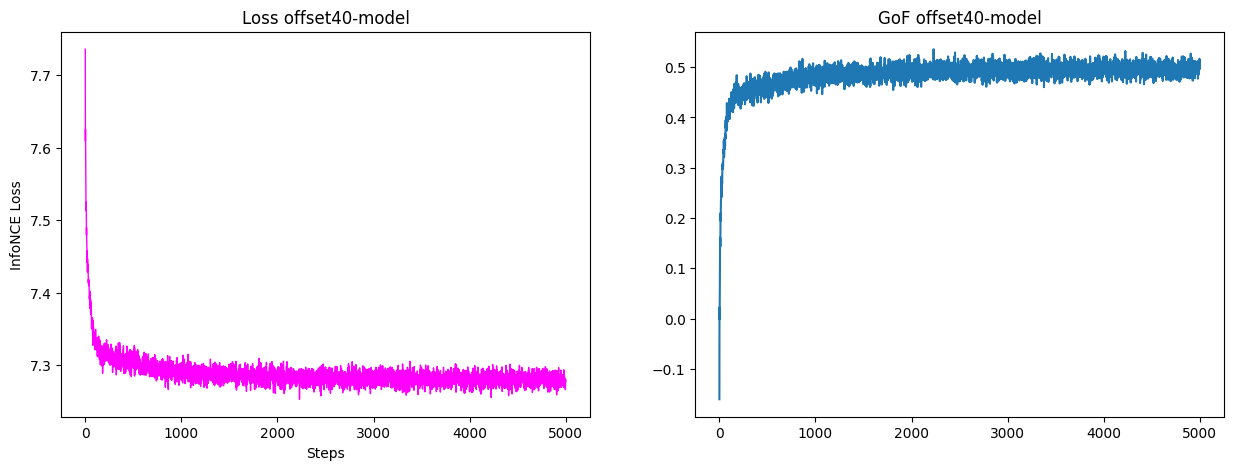

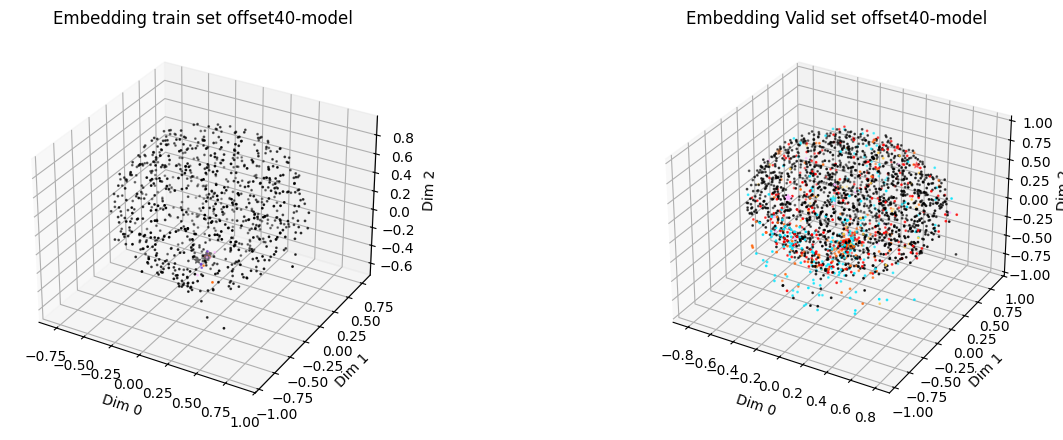

In [58]:
Model_arch = "offset40-model" 
cebra_Offset40= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time_delta',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True,
    hybrid = False
)

print(cebra_Offset40)

# fit the model
print('Fitting the model')
cebra_Offset40.fit(train_data, train_behavior)

# obtain the embedding on training set
print('calculating the training embedding')
embtrain = cebra_Offset40.transform(train_data)
assert(embtrain.shape == (train_data.shape[0],Output_dim))


# obtain the embedding on validating set
print('calculating the validating embedding')
embval = cebra_Offset40.transform(valid_data)
assert(embval.shape == (valid_data.shape[0],Output_dim))

plot_cebra(embtrain[Ind_first4trials[0]:Ind_first4trials[1],:], embval[Ind_last5trials[0]-FS:Ind_last5trials[1],:], cebra_Offset40, Model_arch, train_sensor[Ind_first4trials[0]:Ind_first4trials[1]], train_reward[Ind_first4trials[0]:Ind_first4trials[1]], train_ct[Ind_first4trials[0]:Ind_first4trials[1]], valid_sensor[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_reward[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_ct[Ind_last5trials[0]-FS:Ind_last5trials[1]], ct_dict)
mask_train = gettrialmask(train_sensor, train_reward, train_ct)
mask_val = gettrialmask(valid_sensor, valid_reward, valid_ct)
plot_cebra(embtrain[mask_train,:], embval[mask_val,:], cebra_Offset40, Model_arch, train_sensor[mask_train], train_reward[mask_train], train_ct[mask_train], valid_sensor[mask_val], valid_reward[mask_val], valid_ct[mask_val], ct_dict, PlotLossFlag=False)


CEBRA(batch_size=2048, conditional='time_delta', device='mps',
      learning_rate=0.001, max_iterations=5000,
      model_architecture='offset50-model', output_dimension=5, verbose=True)
Fitting the model


pos: -0.6850 neg:  7.9624 total:  7.2774 temperature:  1.0000: 100%|██████████| 5000/5000 [18:11<00:00,  4.58it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit
plotting the embedding for training data
plotting the embedding for validating data


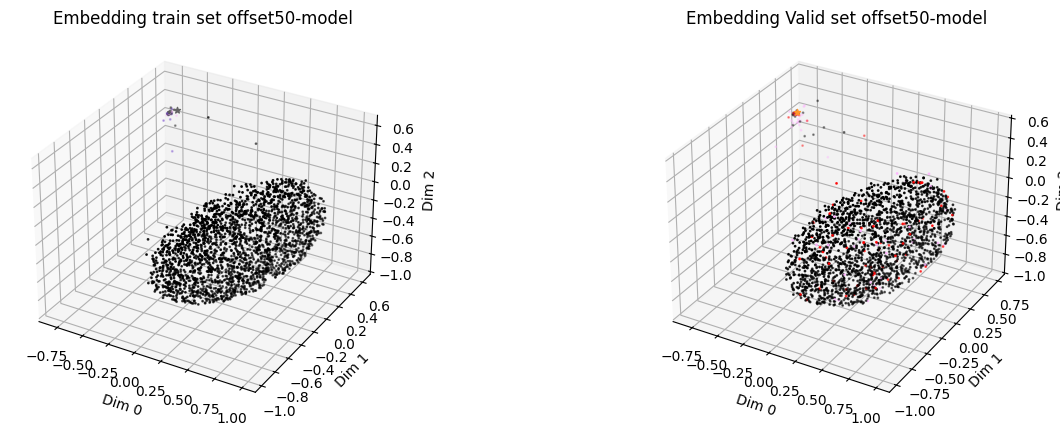

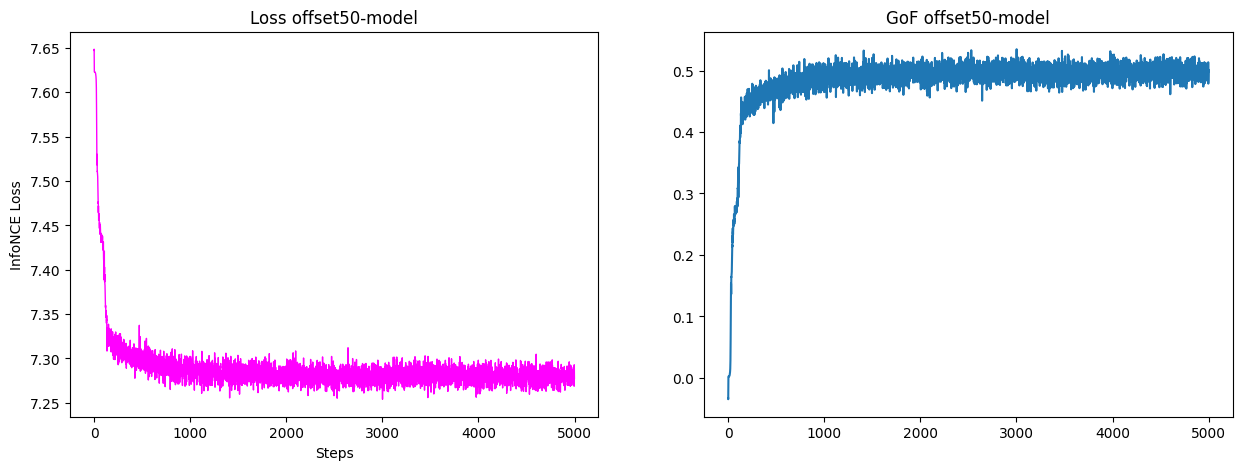

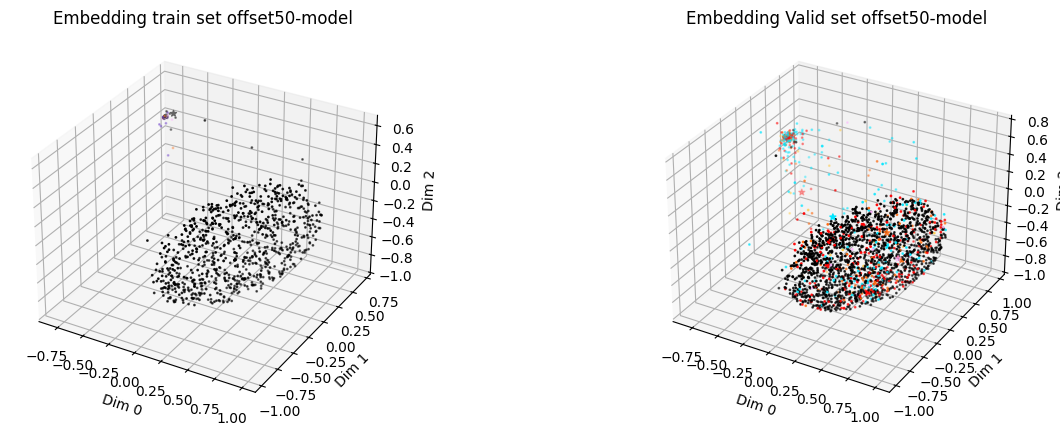

In [59]:
Model_arch = "offset50-model" 
cebra_Offset50= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time_delta',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True,
    hybrid = False
)

print(cebra_Offset50)

# fit the model
print('Fitting the model')
cebra_Offset50.fit(train_data, train_behavior)

# obtain the embedding on training set
print('calculating the training embedding')
embtrain = cebra_Offset50.transform(train_data)
assert(embtrain.shape == (train_data.shape[0],Output_dim))

# obtain the embedding on validating set
print('calculating the validating embedding')
embval = cebra_Offset50.transform(valid_data)
assert(embval.shape == (valid_data.shape[0],Output_dim))

plot_cebra(embtrain[Ind_first4trials[0]:Ind_first4trials[1],:], embval[Ind_last5trials[0]-FS:Ind_last5trials[1],:], cebra_Offset50, Model_arch, train_sensor[Ind_first4trials[0]:Ind_first4trials[1]], train_reward[Ind_first4trials[0]:Ind_first4trials[1]], train_ct[Ind_first4trials[0]:Ind_first4trials[1]], valid_sensor[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_reward[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_ct[Ind_last5trials[0]-FS:Ind_last5trials[1]], ct_dict)
mask_train = gettrialmask(train_sensor, train_reward, train_ct)
mask_val = gettrialmask(valid_sensor, valid_reward, valid_ct)
plot_cebra(embtrain[mask_train,:], embval[mask_val,:], cebra_Offset50, Model_arch, train_sensor[mask_train], train_reward[mask_train], train_ct[mask_train], valid_sensor[mask_val], valid_reward[mask_val], valid_ct[mask_val], ct_dict, PlotLossFlag=False)


CEBRA(batch_size=2048, conditional='time_delta', device='mps',
      learning_rate=0.001, max_iterations=5000,
      model_architecture='offset15-model', output_dimension=5, verbose=True)
Fitting the model


pos: -0.6786 neg:  7.9486 total:  7.2700 temperature:  1.0000: 100%|██████████| 5000/5000 [09:37<00:00,  8.66it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit
plotting the embedding for training data
plotting the embedding for validating data


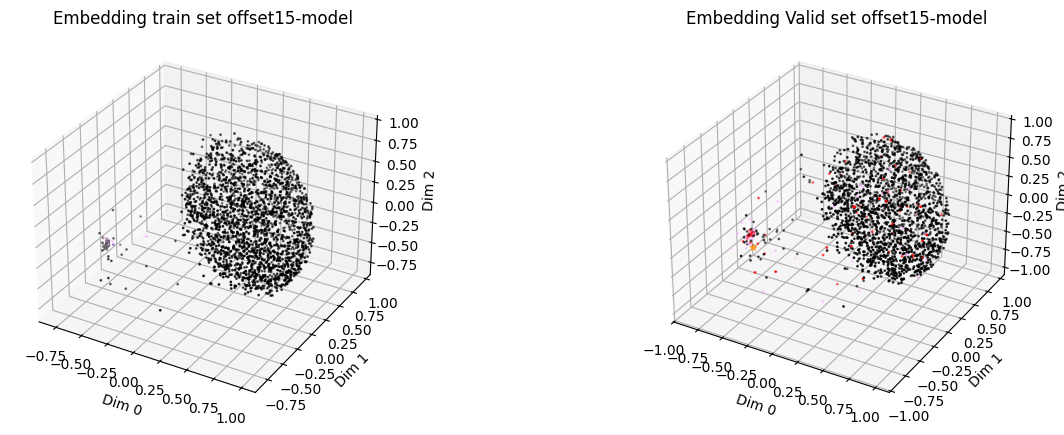

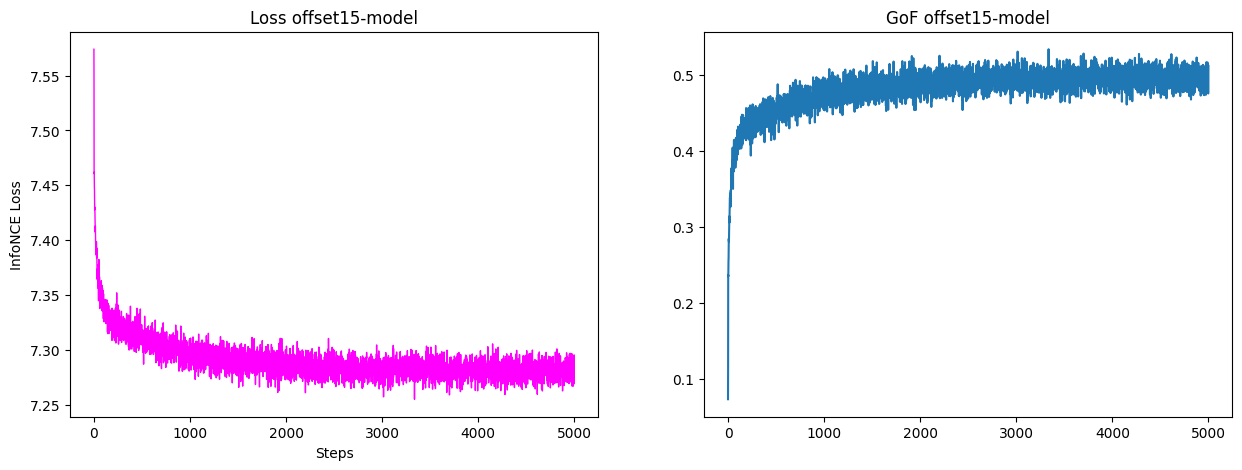

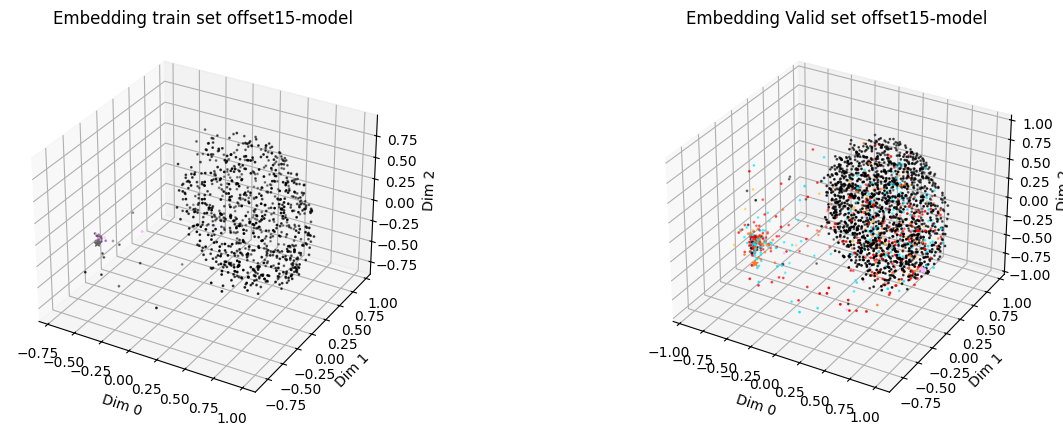

In [60]:
Model_arch = "offset15-model" 
cebra_Offset15= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time_delta',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True,
    hybrid = False
)

print(cebra_Offset15)

# fit the model
print('Fitting the model')
cebra_Offset15.fit(train_data, train_behavior)

# obtain the embedding on training set
print('calculating the training embedding')
embtrain = cebra_Offset15.transform(train_data)
assert(embtrain.shape == (train_data.shape[0],Output_dim))

# obtain the embedding on validating set
print('calculating the validating embedding')
embval = cebra_Offset15.transform(valid_data)
assert(embval.shape == (valid_data.shape[0],Output_dim))

plot_cebra(embtrain[Ind_first4trials[0]:Ind_first4trials[1],:], embval[Ind_last5trials[0]-FS:Ind_last5trials[1],:], cebra_Offset15, Model_arch, train_sensor[Ind_first4trials[0]:Ind_first4trials[1]], train_reward[Ind_first4trials[0]:Ind_first4trials[1]], train_ct[Ind_first4trials[0]:Ind_first4trials[1]], valid_sensor[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_reward[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_ct[Ind_last5trials[0]-FS:Ind_last5trials[1]], ct_dict)
mask_train = gettrialmask(train_sensor, train_reward, train_ct)
mask_val = gettrialmask(valid_sensor, valid_reward, valid_ct)
plot_cebra(embtrain[mask_train,:], embval[mask_val,:], cebra_Offset15, Model_arch, train_sensor[mask_train], train_reward[mask_train], train_ct[mask_train], valid_sensor[mask_val], valid_reward[mask_val], valid_ct[mask_val], ct_dict, PlotLossFlag=False)


CEBRA(batch_size=2048, conditional='time_delta', device='mps',
      learning_rate=0.001, max_iterations=5000,
      model_architecture='offset20-model', output_dimension=5, verbose=True)
Fitting the model


pos: -0.6783 neg:  7.9601 total:  7.2818 temperature:  1.0000: 100%|██████████| 5000/5000 [13:43<00:00,  6.07it/s]


calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss
plotting the goodness of fit
plotting the embedding for training data
plotting the embedding for validating data


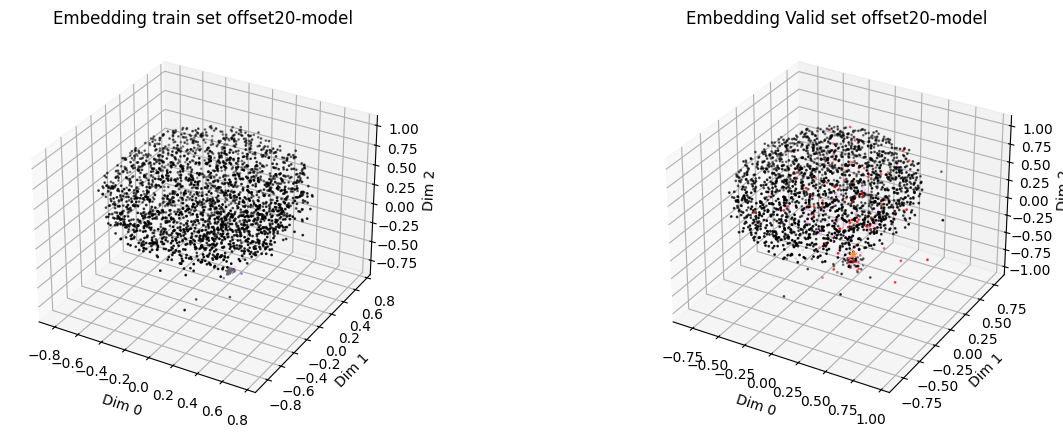

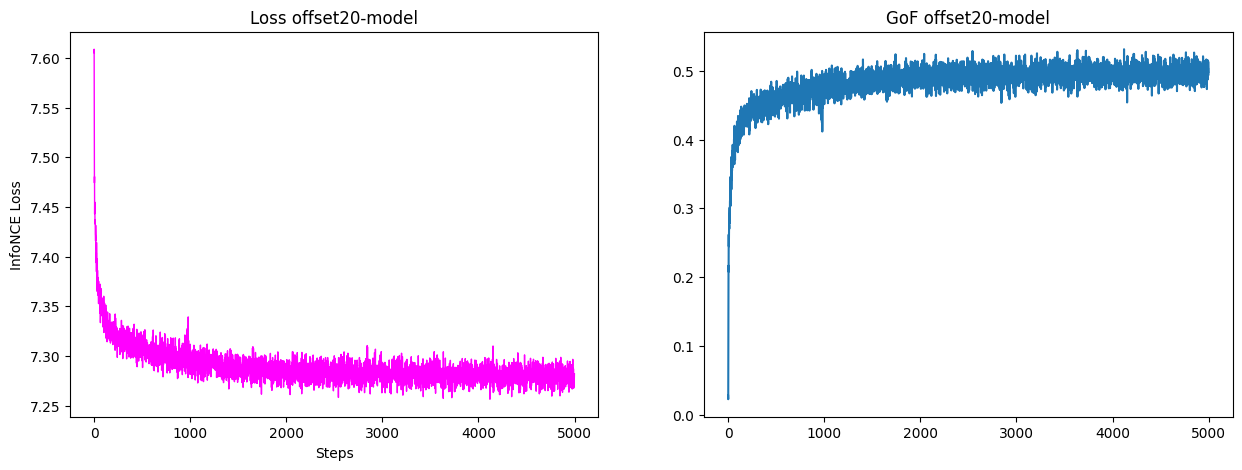

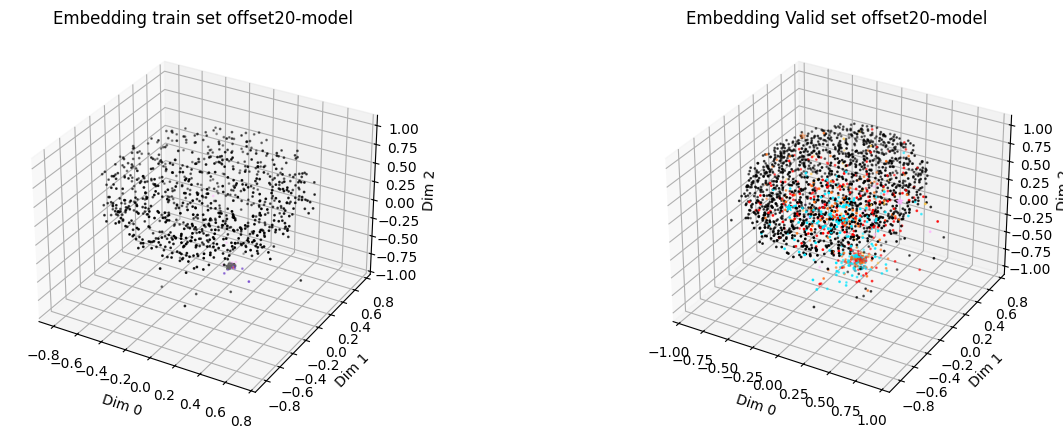

In [61]:
Model_arch = "offset20-model" 
cebra_Offset20= CEBRA(
    model_architecture = Model_arch,
    conditional = 'time_delta',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offset, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = True,
    hybrid = False
)

print(cebra_Offset20)

# fit the model
print('Fitting the model')
cebra_Offset20.fit(train_data, train_behavior)

# obtain the embedding on training set
print('calculating the training embedding')
embtrain = cebra_Offset20.transform(train_data)
assert(embtrain.shape == (train_data.shape[0],Output_dim))

# obtain the embedding on validating set
print('calculating the validating embedding')
embval = cebra_Offset20.transform(valid_data)
assert(embval.shape == (valid_data.shape[0],Output_dim))

plot_cebra(embtrain[Ind_first4trials[0]:Ind_first4trials[1],:], embval[Ind_last5trials[0]-FS:Ind_last5trials[1],:], cebra_Offset20, Model_arch, train_sensor[Ind_first4trials[0]:Ind_first4trials[1]], train_reward[Ind_first4trials[0]:Ind_first4trials[1]], train_ct[Ind_first4trials[0]:Ind_first4trials[1]], valid_sensor[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_reward[Ind_last5trials[0]-FS:Ind_last5trials[1]], valid_ct[Ind_last5trials[0]-FS:Ind_last5trials[1]], ct_dict)
mask_train = gettrialmask(train_sensor, train_reward, train_ct)
mask_val = gettrialmask(valid_sensor, valid_reward, valid_ct)
plot_cebra(embtrain[mask_train,:], embval[mask_val,:], cebra_Offset20, Model_arch, train_sensor[mask_train], train_reward[mask_train], train_ct[mask_train], valid_sensor[mask_val], valid_reward[mask_val], valid_ct[mask_val], ct_dict, PlotLossFlag=False)


<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

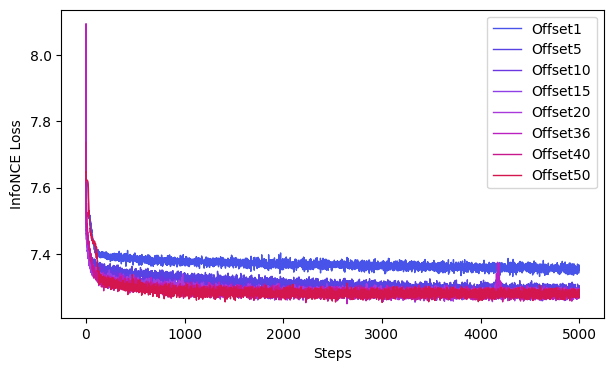

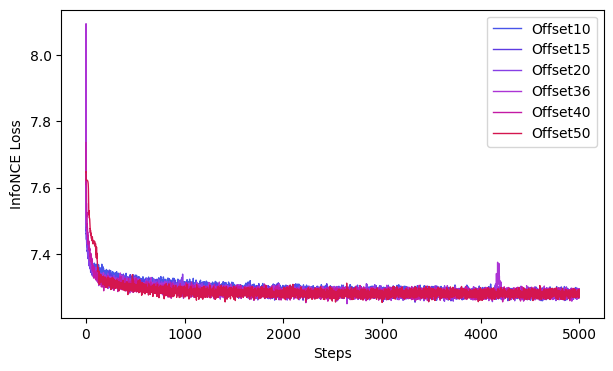

In [62]:
# compare Losses
# Labels to be used for the legend of the plot
labels = ["Offset1","Offset5", "Offset10", "Offset15", "Offset20", "Offset36", "Offset40", "Offset50"]

cebra.compare_models([cebra_Offset1, cebra_Offset5, cebra_Offset10, cebra_Offset15, cebra_Offset20, cebra_Offset36, cebra_Offset40, cebra_Offset50], labels)
# Labels to be used for the legend of the plot
labels = ["Offset10", "Offset15", "Offset20", "Offset36", "Offset40", "Offset50"]

cebra.compare_models([cebra_Offset10, cebra_Offset15, cebra_Offset20, cebra_Offset36, cebra_Offset40, cebra_Offset50], labels)

100%|██████████| 500/500 [00:40<00:00, 12.32it/s]


Text(0.5, 0, 'Filter size')

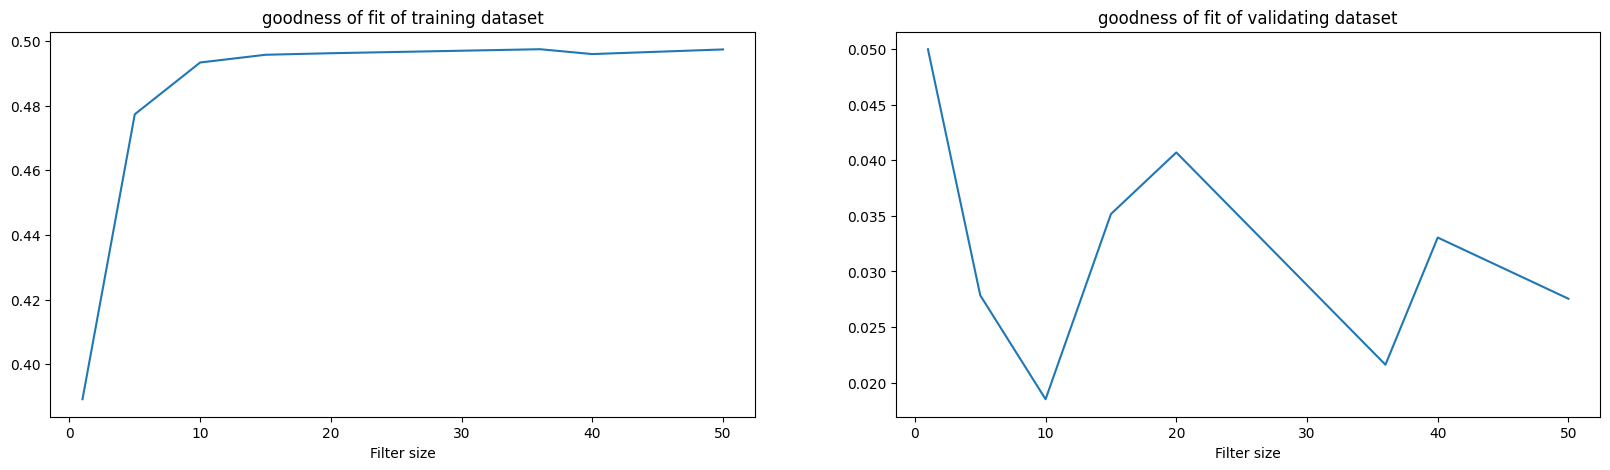

In [65]:
# Evaluate the model performance
goodness_of_fit_train = []
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset1,
                                                     train_data, train_behavior))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset5,
                                                     train_data, train_behavior))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset10,
                                                     train_data, train_behavior))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset15,
                                                     train_data, train_behavior))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset20,
                                                     train_data, train_behavior))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset36,
                                                     train_data, train_behavior))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset40,
                                                     train_data, train_behavior))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset50,
                                                     train_data, train_behavior))
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([1,5,10,15,20,36,40,50], goodness_of_fit_train)
ax1.set_title('goodness of fit of training dataset')
ax1.set_xlabel('Filter size')

goodness_of_fit_valid = []
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset1,
                                                     valid_data, valid_behavior))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset5,
                                                     valid_data, valid_behavior))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset10,
                                                     valid_data, valid_behavior))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset15,
                                                     valid_data, valid_behavior))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset20,
                                                     valid_data, valid_behavior))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset36,
                                                     valid_data, valid_behavior))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset40,
                                                     valid_data, valid_behavior))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_Offset50,
                                                     valid_data, valid_behavior))
ax2 = fig.add_subplot(1,2,2)
ax2.plot([1,5,10,15,20,36,40,50], goodness_of_fit_valid)
ax2.set_title('goodness of fit of validating dataset')
ax2.set_xlabel('Filter size')

Text(0.5, 0, 'Filter size')

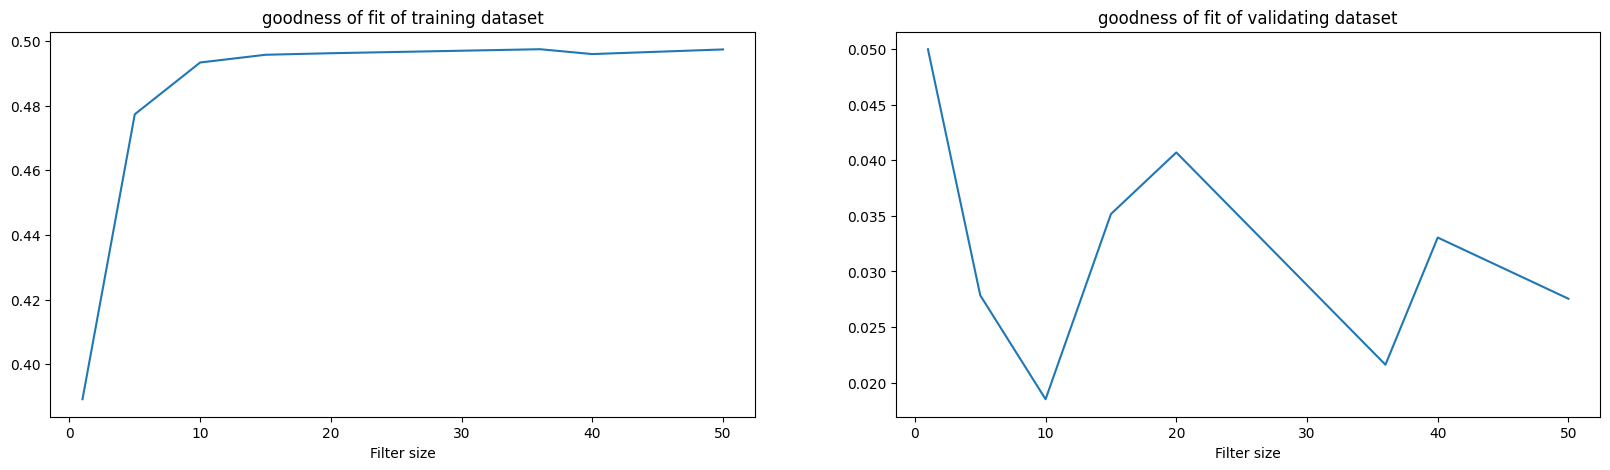

In [66]:
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([1,5,10,15,20,36,40,50], goodness_of_fit_train)
ax1.set_title('goodness of fit of training dataset')
ax1.set_xlabel('Filter size')
ax2 = fig.add_subplot(1,2,2)
ax2.plot([1,5,10,15,20,36,40,50], goodness_of_fit_valid)
ax2.set_title('goodness of fit of validating dataset')
ax2.set_xlabel('Filter size')

In [67]:
modelArch_Filter_size = [1,5,10,15,20,36,40,50]
neuro_path = '/Users/elie/Library/CloudStorage/Box-Box/ManipBerkeleyZF/neuro_PurWhi_WF/'
filename = '%s/GoodnessFit_countData_Modvar_Behav_TimeOffset1_Dim5.pkl' % (neuro_path)
with open(filename, 'wb') as f:
    pickle.dump({'goodness_of_fit_train': goodness_of_fit_train, 'goodness_of_fit_valid': goodness_of_fit_valid, 'Filter_size': modelArch_Filter_size}, f)

In [68]:
goodness_of_fit_valid

[0.04998832324608721,
 0.027852324808777022,
 0.018503008070157315,
 0.03516313256258129,
 0.04070264696759134,
 0.021606842259892782,
 0.03304745289853233,
 0.027541680113760642]